# Machine Learning Foundation

## Support Vector Machines (SVM) - Lecture Notes


Support Vector Machines (SVM) introduces a completely different, highly geometric way of thinking about classification.

At its core, a Support Vector Machine (SVM) searches for the ultimate boundary between classes. Instead of just finding any line that separates the data, SVM looks for the specific line (or hyperplane in higher dimensions) that maximizes the distance between the two closest points of opposite classes.

Think of it as building a wide, clear highway between your data points. The middle of that highway is the decision boundary.

### How It Differs From Logistic Regression and KNN

The easiest way to understand SVM is to contrast how they make decisions.

1. SVM vs. Logistic Regression (The Objective)

    Logistic Regression is probabilistic. It cares about all the data points and tries to maximize the likelihood of the data fitting a sigmoid curve. It can be easily influenced by far-away, confident points.

    SVM is geometric. It only cares about the toughest points to classify—the ones right on the edge. It tries to maximize the margin (the width of the highway). If we add a million more data points deep inside the correct class regions, an SVM's boundary won't budge at all.

2. SVM vs. KNN (The Strategy)

    KNN is a lazy learner. It doesn't actually "learn" a boundary during training; it just stores the data. When we give it a new point, it has to calculate the distance to its neighbors in real-time. It struggles heavily if we have a lot of features (the curse of dimensionality).

    SVM is an eager learner. It does the heavy lifting during training to find that optimal boundary. Once found, it throws away most of the data and only keeps a few key points. When a new point arrives, it just checks which side of the line it falls on, making prediction incredibly fast.

### The Key Concepts

To speak SVM fluently, there are three main terms to know:

* **Hyperplane**: The decision boundary. In 2D, it's a line; in 3D, it's a flat plane; in higher dimensions, we call it a hyperplane.

* **Support Vectors**: These are the critical data points that sit right on the edge of the margin. They are the only points holding up the boundary. If we remove them, the boundary moves. If we remove any other point, nothing happens.

* **The Kernel Trick**: What happens if our data looks like a donut, where a straight line can't separate the classes? SVM uses "kernels" to mathematically project the data into a higher dimension where a straight, flat plane can cleanly cut through it. It does this without the massive computational cost of actually transforming every point.

### Summary Comparison

|Metric|KNN|Logistic Regression|SVM|
|---|---|---|---|
|What it learns|Nothing (lazy)|A probability distribution|A geometric maximum-margin boundary|
|Key data points|All neighbors at prediction time|All training points influence the curve|Only the Support Vectors on the margin|
|Handles non-linear data|Naturally (based on local density)|Needs manual feature engineering|Exceptionally well via the Kernel Trick|
|Memory footprint|High (must keep all data)|Low (only keeps weights)|Low (only keeps support vectors)|

##

<BR>

<img src="images/SVM/SVM_forDataScientist.jpg" width="65%">

<BR>

<BR>

___

## Support Vector Machines - Demo Lab

## Introduction

We will be using the wine quality data set for these exercises. This data set contains various chemical properties of wine, such as acidity, sugar, pH, and alcohol. It also contains a quality metric (3-9, with highest being better) and a color (red or white). The name of the file is `Wine_Quality_Data.csv`.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

## Part 1: Setup

* Import the data.
* Create the target variable `y` as a 1/0 column where 1 means red.
* Create a `pairplot` for the dataset.
* Create a bar plot showing the correlations between each column and `y`
* Pick the most 2 correlated fields (using the absolute value of correlations) and create `X`
* Use MinMaxScaler to scale `X`. Note that this will output a np.array. Make it a DataFrame again and rename the columns appropriately.


In [2]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Wine_Quality_Data.csv"

data = pd.read_csv("data/Wine_Quality_Data.csv", sep=',')


In [3]:
y = (data['color'] == 'red').astype(int)
fields = list(data.columns[:-1])  # everything except "color"
correlations = data[fields].corrwith(y)
correlations.sort_values(inplace=True)
correlations

total_sulfur_dioxide   -0.700357
free_sulfur_dioxide    -0.471644
residual_sugar         -0.348821
citric_acid            -0.187397
quality                -0.119323
alcohol                -0.032970
pH                      0.329129
density                 0.390645
fixed_acidity           0.486740
sulphates               0.487218
chlorides               0.512678
volatile_acidity        0.653036
dtype: float64

In [4]:
sns.set_context('talk')
#sns.set_palette(palette)
sns.set_style('white')

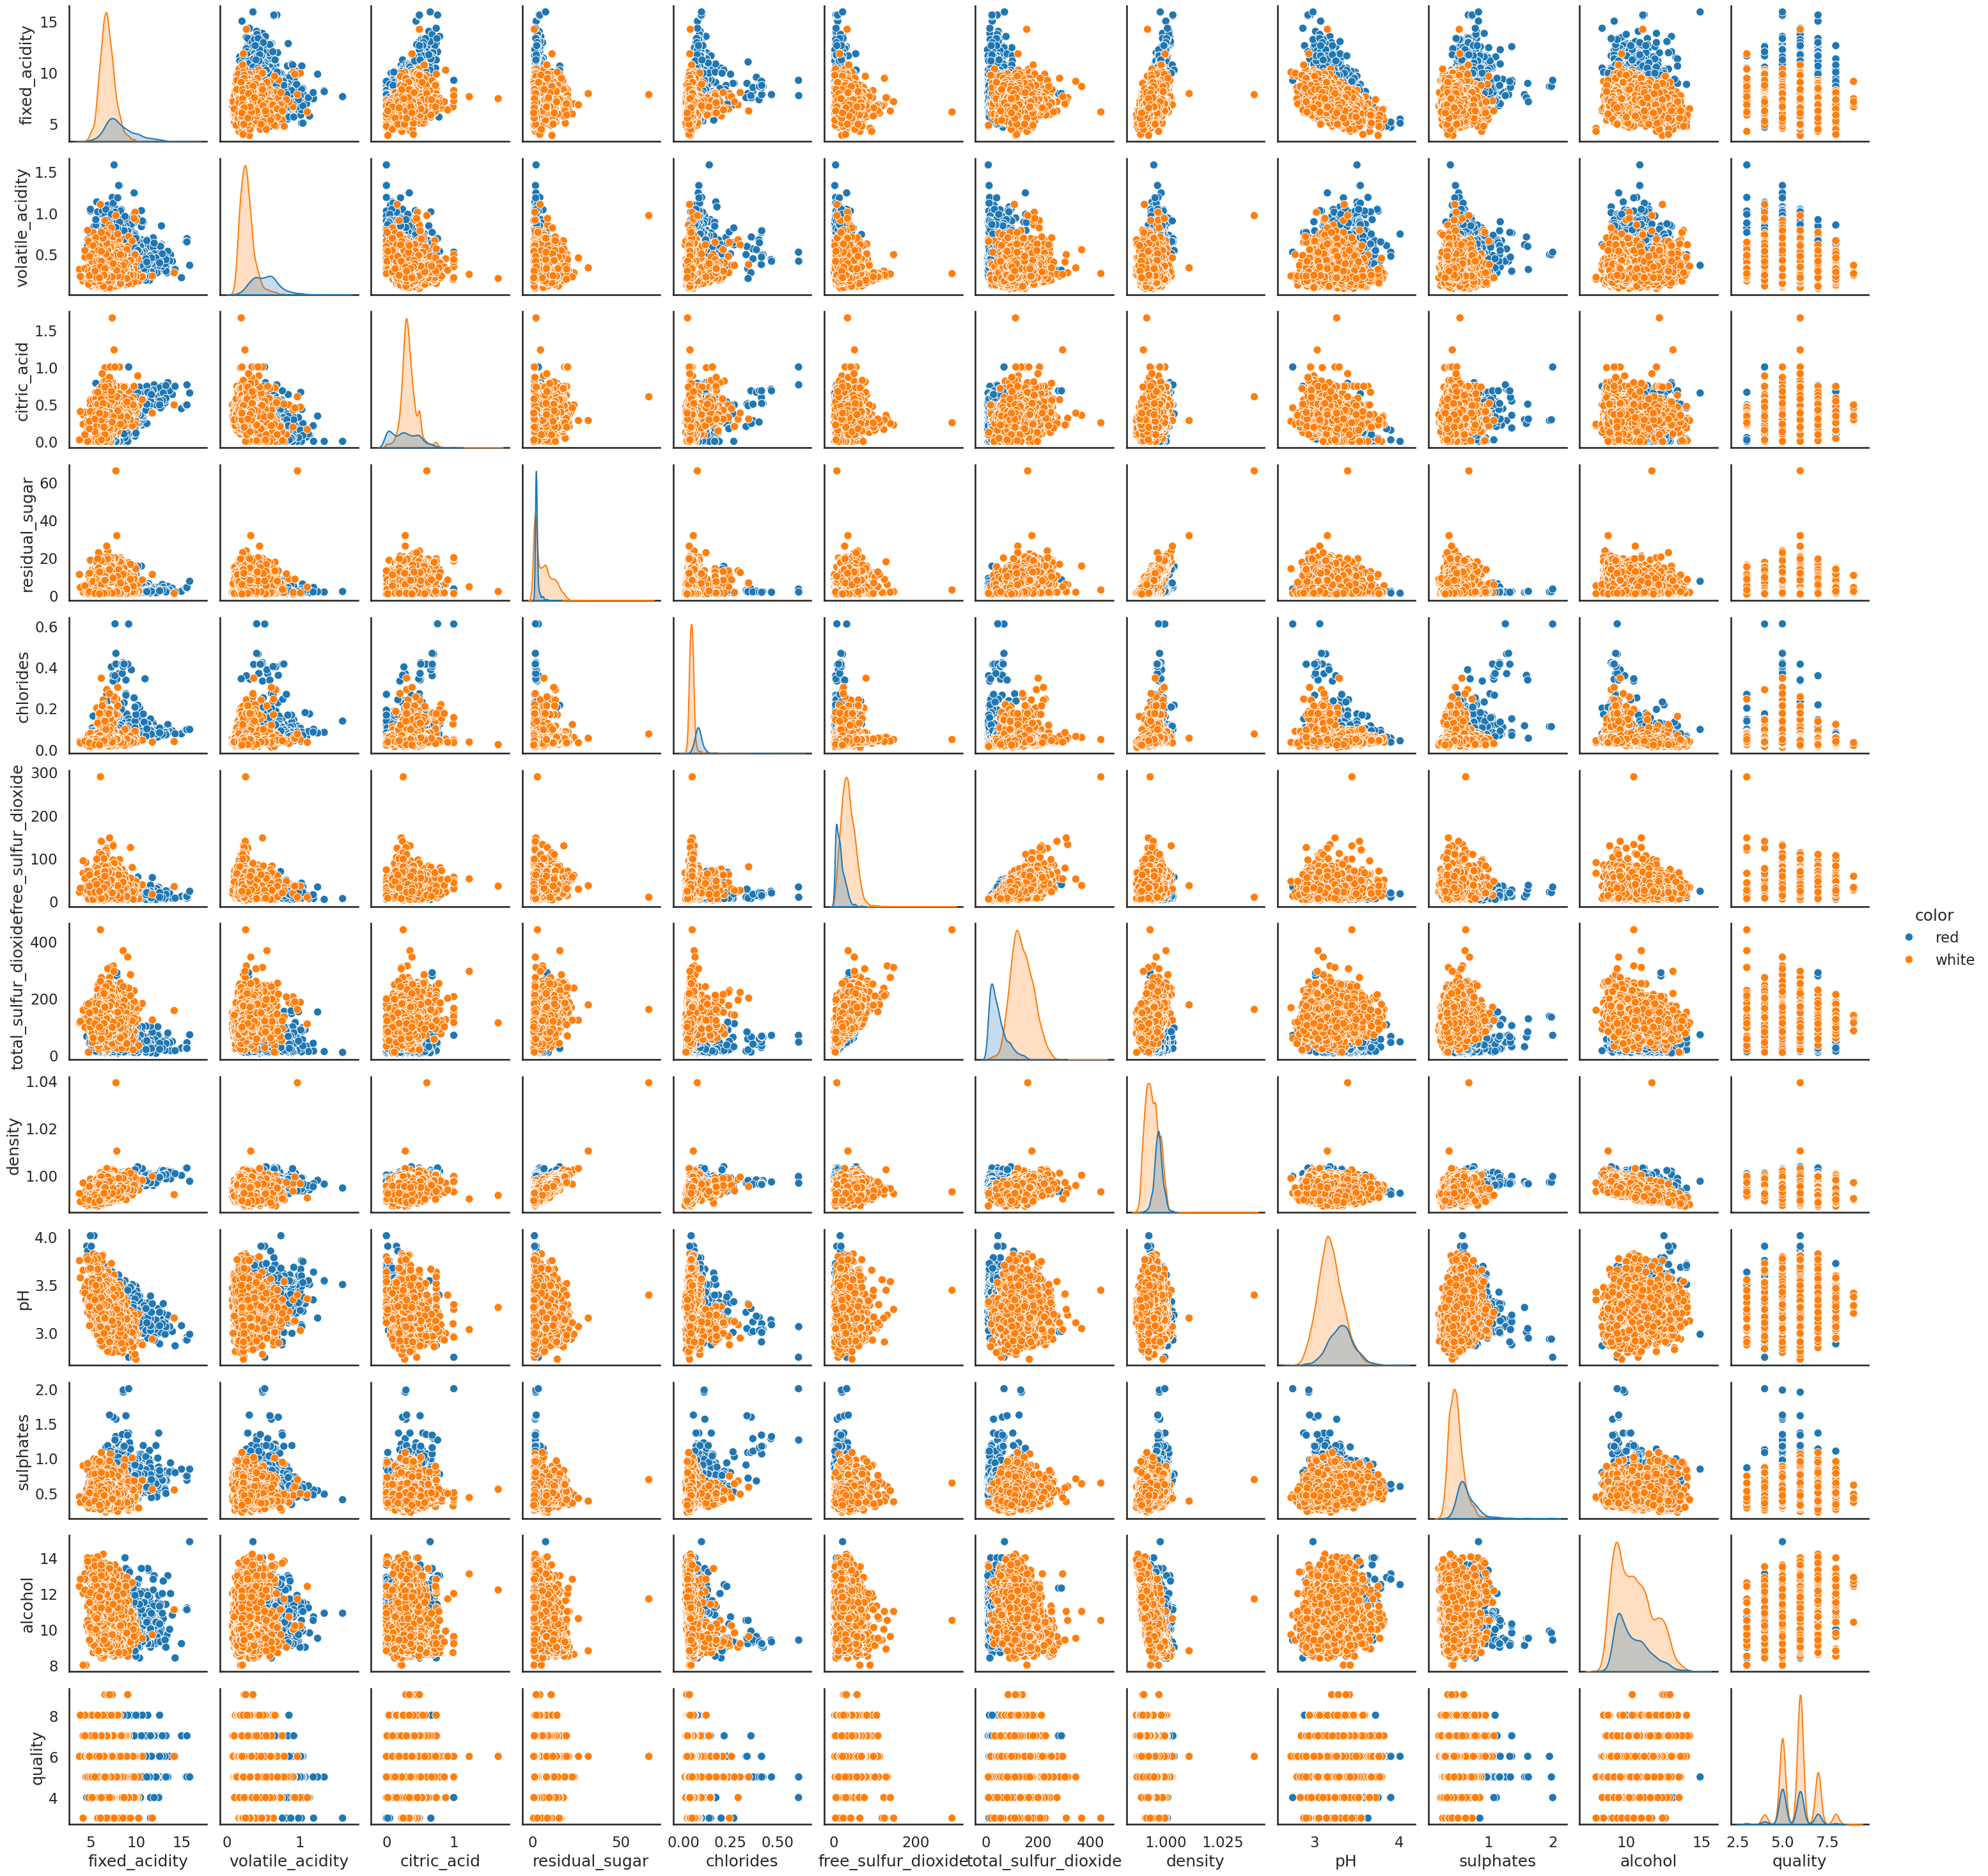

In [5]:
sns.pairplot(data, hue='color')

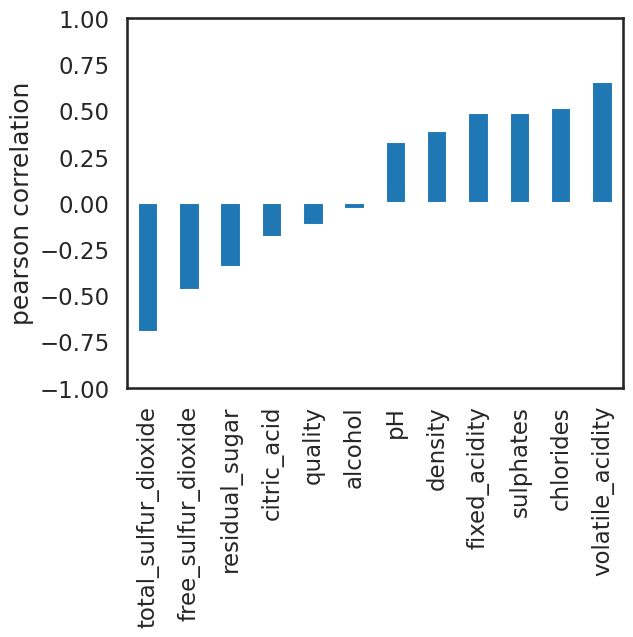

In [6]:
ax = correlations.plot(kind='bar')
ax.set(ylim=[-1, 1], ylabel='pearson correlation');

In [7]:
from sklearn.preprocessing import MinMaxScaler

fields = correlations.map(abs).sort_values().iloc[-2:].index # highest correlated 2 fields with y value
print(fields)

X = data[fields] # we are only using 2 features so that we can visualize in out 2D plot
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X = pd.DataFrame(X, columns=['%s_scaled' % fld for fld in fields])
print(X.columns)

Index(['volatile_acidity', 'total_sulfur_dioxide'], dtype='str')
Index(['volatile_acidity_scaled', 'total_sulfur_dioxide_scaled'], dtype='str')


## Part 2: Linear Decision Boundary

Our goal is to look at the decision boundary of a LinearSVC classifier on this dataset. Check out [this example](https://scikit-learn.org/stable/auto_examples/svm/plot_iris_svc.html#sphx-glr-auto-examples-svm-plot-iris-svc-py) in sklearn's documentation. 

* Fit a Linear Support Vector Machine Classifier to `X`, `y`.
* Pick 300 samples from `X`. Get the corresponding `y` value. Store them in variables `X_color` and `y_color`. This is because original dataset is too large and it produces a crowded plot.
* Modify `y_color` so that it has the value "red" instead of 1 and 'yellow' instead of 0.
* Scatter plot X_color's columns. Use the keyword argument "color=y_color" to color code samples.
* Use the code snippet below to plot the decision surface in a color coded way.

```python
x_axis, y_axis = np.arange(0, 1, .005), np.arange(0, 1, .005)
xx, yy = np.meshgrid(x_axis, y_axis)
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
X_grid = pd.DataFrame([xx_ravel, yy_ravel]).T
y_grid_predictions = *[YOUR MODEL]*.predict(X_grid)
y_grid_predictions = y_grid_predictions.reshape(xx.shape)
ax.contourf(xx, yy, y_grid_predictions, cmap=colors, alpha=.3)
```

With LinearSVC, it is easy to experiment with different parameter choices and see the decision boundary.


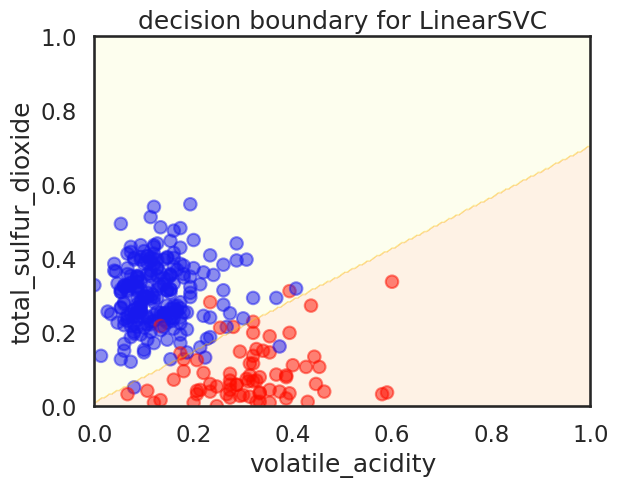

In [8]:
from sklearn.svm import LinearSVC

LSVC = LinearSVC()
LSVC.fit(X, y)

# to avoid over crowding, we are only plotting 300 points
X_color = X.sample(300, random_state=45)
y_color = y.loc[X_color.index]
y_color = y_color.map(lambda r: 'red' if r == 1 else 'blue')

ax = plt.axes()
ax.scatter(
    X_color.iloc[:, 0], X_color.iloc[:, 1],
    color=y_color, alpha=.5)

# draw the background color and boundary
x_axis, y_axis = np.arange(0, 1.005, .005), np.arange(0, 1.005, .005)
xx, yy = np.meshgrid(x_axis, y_axis)
xx_ravel = xx.ravel()
yy_ravel = yy.ravel()
X_grid = pd.DataFrame([xx_ravel, yy_ravel], index=X.columns).T
y_grid_predictions = LSVC.predict(X_grid)
y_grid_predictions = y_grid_predictions.reshape(xx.shape)
ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.Wistia, alpha=.1)

# set axis labels and title
ax.set(
    xlabel=fields[0],
    ylabel=fields[1],
    xlim=[0, 1],
    ylim=[0, 1],
    title='decision boundary for LinearSVC');

## Part 3: Gaussian Kernel


Let's now fit a Gaussian kernel SVC and see how the decision boundary changes.

* Consolidate the code snippets in Question 2 into one function which takes in an estimator, `X` and `y`, and produces the final plot with decision boundary. The steps are:
    <ol>
     <li> Fit model
     <li> Get sample 300 records from X and the corresponding y's
     <li> Create grid, predict, plot using ax.contourf
     <li> Add on the scatter plot
    </ol>
* After copying and pasting code, the finished function uses the input `estimator` and not the LinearSVC model.
* For the following values of `gamma`, create a Gaussian Kernel SVC and plot the decision boundary.  
`gammas = [.5, 1, 2, 10]`
* Holding `gamma` constant, we plot the decision boundary for various values of `C`: 
`[.1, 1, 10]`

In [9]:
def plot_decision_boundary(estimator, X, y):
    estimator.fit(X, y)
    X_color = X.sample(300)
    y_color = y.loc[X_color.index]
    y_color = y_color.map(lambda r: 'red' if r == 1 else 'blue')
    
    x_axis, y_axis = np.arange(0, 1, .005), np.arange(0, 1, .005)
    xx, yy = np.meshgrid(x_axis, y_axis)
    xx_ravel = xx.ravel()
    yy_ravel = yy.ravel()
    X_grid = pd.DataFrame([xx_ravel, yy_ravel], index=X.columns).T
    y_grid_predictions = estimator.predict(X_grid)
    y_grid_predictions = y_grid_predictions.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
    ax.scatter(X_color.iloc[:, 0], X_color.iloc[:, 1], color=y_color, alpha=.5)
    ax.set(
        xlabel=fields[0],
        ylabel=fields[1],
        title=str(estimator))

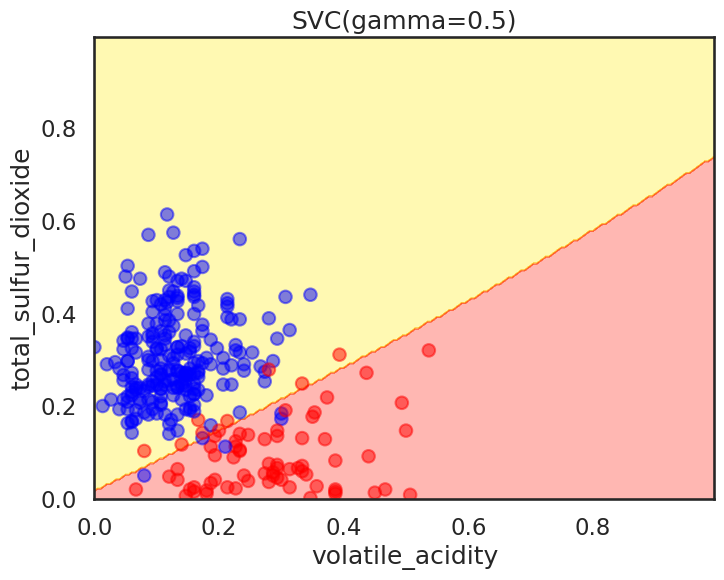

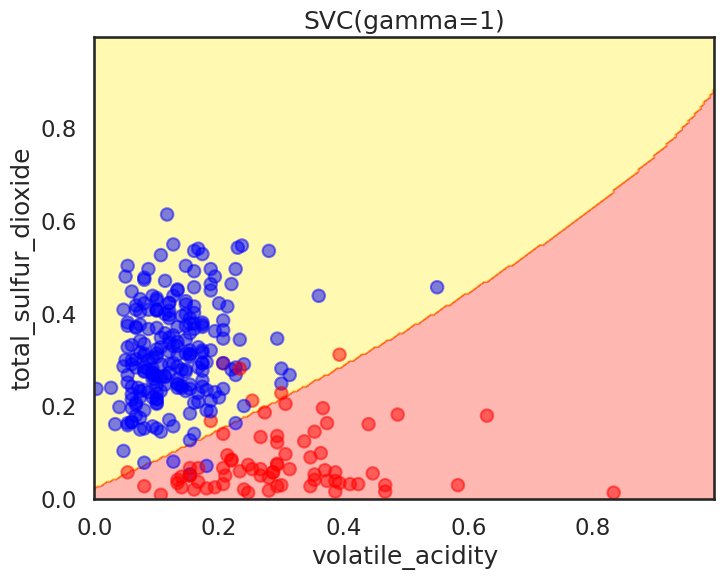

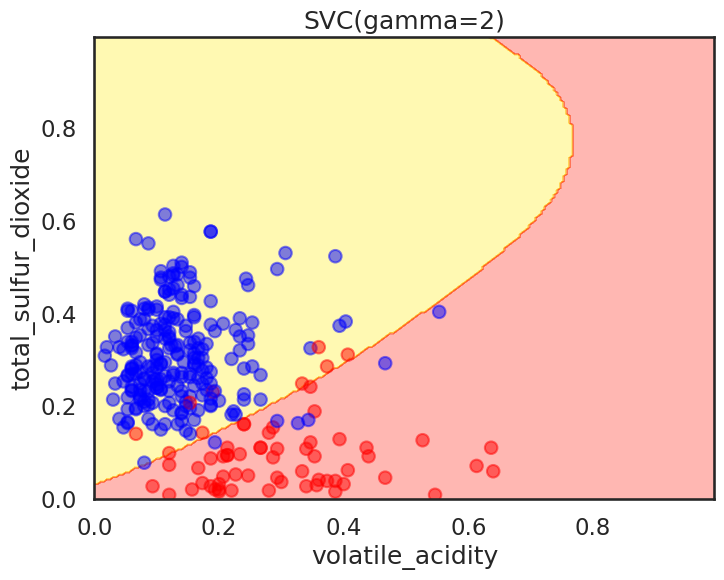

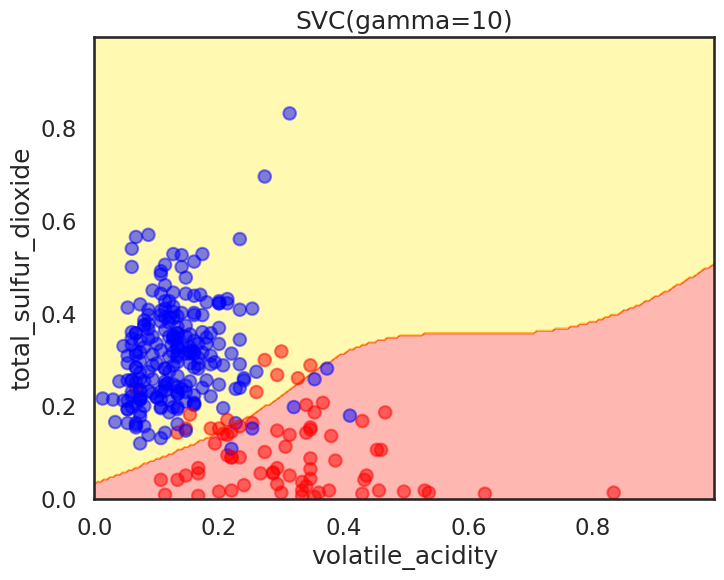

In [10]:
from sklearn.svm import SVC

gammas = [.5, 1, 2, 10]
for gamma in gammas:
    SVC_Gaussian = SVC(kernel='rbf', gamma=gamma)
    plot_decision_boundary(SVC_Gaussian, X, y)

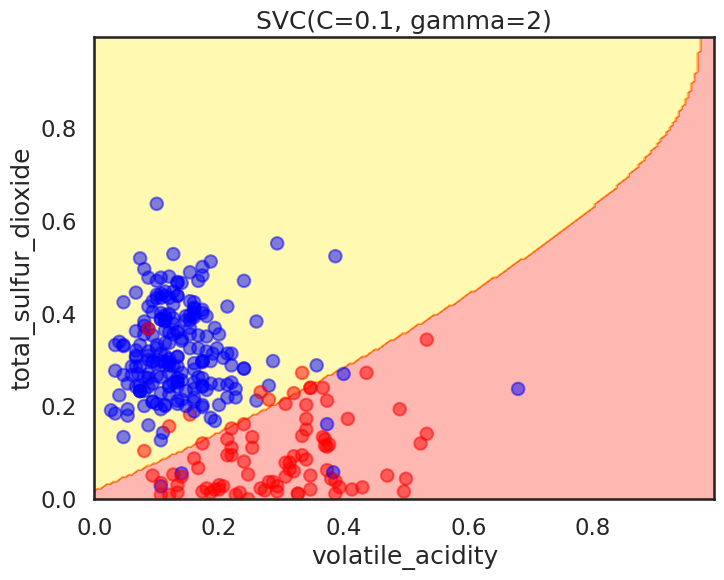

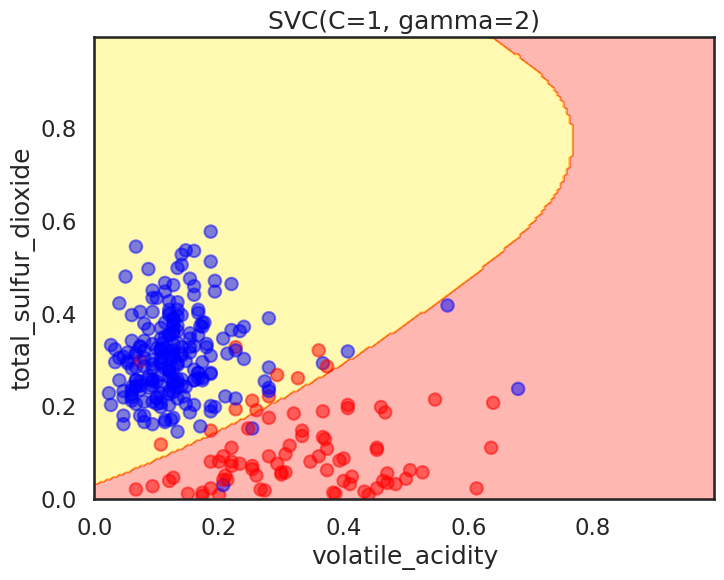

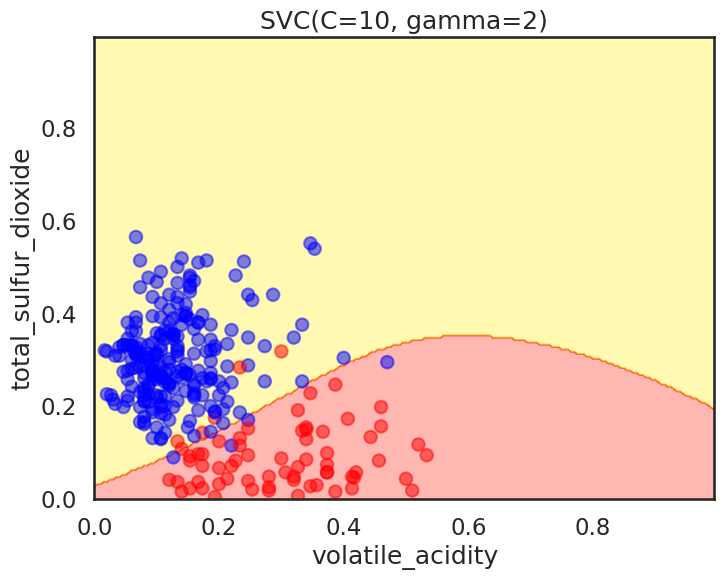

In [11]:
Cs = [.1, 1, 10]
for C in Cs:
    SVC_Gaussian = SVC(kernel='rbf', gamma=2, C=C)
    plot_decision_boundary(SVC_Gaussian, X, y)

## Choosing the right hyperparameters for a Gaussian RBF (Radial Basis Function) SVM

Choosing the right hyperparameters for a Gaussian RBF (Radial Basis Function) SVM comes down to finding the sweet spot between underfitting (too simple) and overfitting (too complex).

When working with a Gaussian SVM, there are two main dials to turn: gamma and C. Understanding how they interact is the key to picking the right model.

1. Understanding the Two Dials

    **Gamma** ($\gamma$): The Radius of InfluenceGamma controls how far the influence of a single training example reaches.

    * Low Gamma: The radius of influence is wide. The model considers points far away from each other when drawing the boundary. This results in a smooth, generalized, and smoother decision boundary (high bias, low variance).

    * High Gamma: The radius of influence is narrow and tight. The model only considers points very close to the boundary. This creates "islands" or highly intricate, squiggly pockets around individual data points (low bias, high variance / overfitting).

    **C: The Penalty Factor**
    At its default value (C=1.0), C controls the trade-off between a smooth boundary and classifying training points correctly.

    * Low C: The model prioritizes a wider margin and a simpler boundary, ignoring misclassified points (soft margin).

    * High C: The model heavily penalizes misclassifications, forcing the boundary to bend and twist to get every single training point right (hard margin).

<BR>

2. How to Decide Which One is "Right"

    Here is the framework to find the right combination:

    Step 1: Don't trust the training plots alone
        If we pick the gamma value alone that looks best on our plots, we run a high risk of picking an overfitted model (like gamma=10), which looks perfect on the training data but will fail in the real world.

    Step 2: Implement Cross-Validation
        Instead of manually guessing, use GridSearchCV from scikit-learn. It splits the data into chunks, trains on some, validates on others, and calculates an unbiased score for every combination of gamma and C.

    Step 3: Check the Visual "Sanity Test"
        Once GridSearchCV gives us the best estimator, plot it. If the boundary looks like a smooth, natural curve that separates the red and blue clusters well, it's a keeper. If the boundary looks like a jagged starburst or has isolated little circles completely surrounding individual dots, our parameter grid might be pushing the model to overfit, and we should try testing lower ranges of gamma and C.

<BR>

Here is how we can update our workflow to let math find the right hyperparameters for us:

Best Parameters: {'C': 1, 'gamma': 0.5}
Best Cross-Validation Score: 0.9579


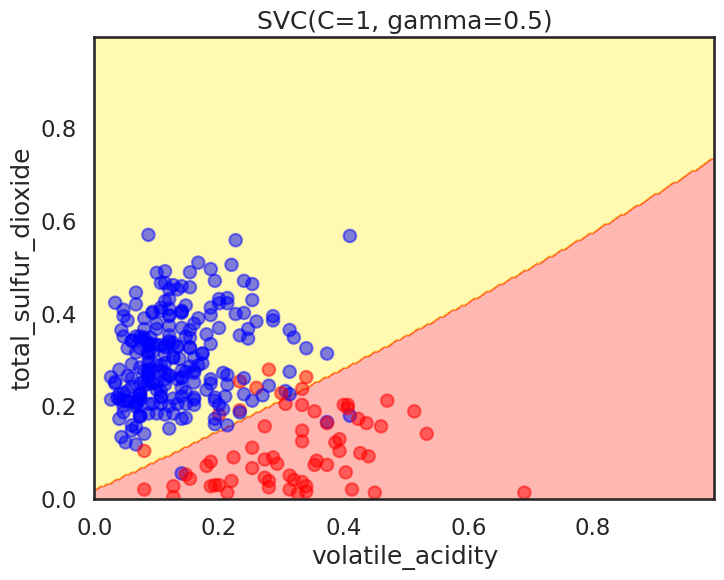

In [12]:
from sklearn.model_selection import GridSearchCV, train_test_split

# 1. Split into train and test sets so you have an untouched evaluation pool
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define a grid of values you want to test
param_grid = {
    'gamma': [0.1, 0.5, 1, 2, 10],
    'C': [0.1, 1, 10, 100]
}

# 3. Setup the Grid Search with Cross-Validation (e.g., 5-fold)
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 4. See what the best parameters are
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# 5. Plot the decision boundary of your winner!
best_model = grid_search.best_estimator_
plot_decision_boundary(best_model, X_train, y_train)

The above plot looks excellent. For a starting baseline model (gamma=0.5), this is exactly what we want to see.

Here is a breakdown of why this visual output confirms our model is on the right track:
1. Great Separation with High Generality

    The decision boundary is a smooth, clean line that very naturally separates the bulk of the blue cluster (top-left) from the red cluster (bottom-right). It isn't aggressively twisting or bending just to capture a few stray points, which means it will likely generalize very well to unseen data.

2. Low Gamma is Doing Its Job

    Because gamma=0.5 is relatively low, the "radius of influence" of individual points is broad. Notice how it creates a single, global decision boundary rather than creating weird little "islands" of red inside the blue territory or vice versa.

3. Handling the Overlap (Soft Margin)

    Look closely at the overlapping region—specifically around volatile_acidity between 0.2 and 0.4. There are a few blue dots falling into the red zone and a few red dots falling into the yellow/blue zone. This is a good thing. An overly complex model would have tried to draw loops around those individual rogue dots. By ignoring those minor intrusions, our model avoids overfitting to noise in the data.

**What to expect as the loop continues:**

As our code progresses through the other gamma values (1, 2, 10), keep an eye on how that straight-looking boundary changes:

* At gamma=1 and 2, we will start to see the boundary curve more dynamically around the edges of the blue cluster.

* At gamma=10, the boundary will likely start wrapping very tightly around the data points, potentially creating isolated pockets. If it starts looking like a jagged coastline, that’s our cue that the model is beginning to overfit.

This gamma=0.5 plot is our gold standard for a clean, stable model. Compare the next outputs to this one to see if the added complexity actually helps capture the shape better, or just creates unnecessary wrinkles!

<BR>

**How the $C$ Value Affects the Boundary**

The $C$ parameter acts as a penalty for misclassification. It tells the SVM how much we care about training errors versus having a smooth, simple boundary.

* Low $C$ (e.g., $C = 0.1$): * The Mindset: "Relaxed."
    * The Effect: The model prioritizes a large, wide margin over perfect classification. It allows data points to violate the boundary or cross into the wrong side if it means keeping the boundary smooth and straight.
    * Visual Change: The line will look very similar to your current plot—smooth, highly generalized, and ignoring those overlapping points in the middle.
* High $C$ (e.g., $C = 100$): * The Mindset: "Strict perfectionist."
    * The Effect: The model heavily penalizes any misclassified points. It will force the decision boundary to bend, twist, and squeeze through tight gaps to make sure every single red and blue dot is on its correct side.
    * Visual Change: The boundary will lose its clean, straight look. It will start zig-zagging aggressively around the overlapping points between $0.2$ and $0.4$ on your x-axis to make sure it leaves no point behind.

<BR>

**Summary of the Effects of Gamma and C**

* Gamma operates at the micro level: It alters the local physics of the space right around individual points. Changing gamma physically changes how far a single point's gravity stretches out to bend the boundary.

* C operates at the macro level: It is the overall management policy. It sits above everything and determines the global tolerance level for the entire system, dictating whether the boundary should prioritize high-level smoothness or hard-line classification perfection. 

## Part 4: Comparing Kernel Execution Times

In this exercise, we will compare the fitting times between SVC vs Nystroem with rbf kernel.  
<br><br>

### What is Nystroem?

Nystroem (specifically Nystroem in scikit-learn) is a brilliant mathematical shortcut designed to solve the biggest flaw of kernel-based models like our Gaussian RBF SVM: they get incredibly slow and memory-heavy when the dataset grows.

If you try to run a standard SVC(kernel='rbf') on a dataset with $100,000$ rows, your computer will likely freeze or take ages to finish. Nystroem() fixes this.

Here is what it is, how it works, and why it's a game-changer.

### The Problem: The "Kernel Matrix" Bottleneck

When you use SVC(kernel='rbf'), the model calculates a distance matrix between every single pair of points in your dataset.

If you have $N$ data points, it creates an $N \times N$ matrix.
* For $1,000$ rows, it’s a $1,000 \times 1,000$ matrix (easy).
* For $100,000$ rows, it’s a $100,000 \times 100,000$ matrix. That requires holding 10 billion values in your RAM just to train the model ($O(N^2)$ memory and $O(N^3)$ time complexity)!

Because of this, standard RBF SVMs do not scale to large datasets.

### The Solution: What Nystroem() Does

The Nystroem method is an approximate feature map. Instead of calculating the relationships between all points, it randomly selects a small, representative subset of your data points (called "components") and calculates the kernel approximations based only on them.

Essentially, it cheats. Instead of measuring how every house in a city relates to every other house, it picks 100 landmark houses and measures how every house relates to those 100 landmarks.

This transforms your data into a lower-dimensional, linear space that mimics the complex RBF infinite-dimensional space.

### How You Use It in Code

Instead of using the heavy SVC(kernel='rbf'), you use Nystroem as a preprocessing step to transform your data, and then hand that data to a blazing-fast linear model like LinearSVC or LogisticRegression or SGDClassifier.

<BR><BR>

Jupyter Notebooks provide a useful magic function **`%timeit`** which executes a line and prints out the time it took to fit. If we type **`%%timeit`** in the beginning of the cell, it will output the execution time.

We proceed with the following steps:
* Create `y` from data.color, and `X` from the rest of the columns.
* Use `%%timeit` to get the time for fitting an SVC with rbf kernel.
* Use `%%timeit` to get the time for the following: fit_transform the data with Nystroem and then fit a SGDClassifier.

Nystroem+SGD will take much less to fit. This difference will be more pronounced if the dataset was bigger.

* Make 5 copies of X and concatenate them
* Make 5 copies of y and concatenate them
* Compare the time it takes to fit the both methods above


In [13]:
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

y = data.color == 'red'
X = data[data.columns[:-1]] # here we use all the features

kwargs = {'kernel': 'rbf'}
svc = SVC(**kwargs)
nystroem = Nystroem(**kwargs) # kernel approximator to save processing time for very large data
sgd = SGDClassifier()

In [14]:
%%timeit
svc.fit(X, y)

182 ms ± 816 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [15]:
%%timeit
X_transformed = nystroem.fit_transform(X)
sgd.fit(X_transformed, y)

136 ms ± 11.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [16]:
X2 = pd.concat([X]*5)
y2 = pd.concat([y]*5)

print(X2.shape)
print(y2.shape)

(32485, 12)
(32485,)


In [17]:
%timeit svc.fit(X2, y2)

4.1 s ± 6.64 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
%%timeit
X2_transformed = nystroem.fit_transform(X2)
sgd.fit(X2_transformed, y2)

192 ms ± 37 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Alternatively, we can use a Pipeline.

In [20]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline

# 1. Instantiate Nystroem to approximate an RBF kernel
# n_components is how many 'landmark' points to pick. More components = more accurate but slower.
nystroem_approximation = Nystroem(kernel='rbf', gamma=0.5, n_components=100, random_state=42)

# 2. Pair it with a LinearSVC (which scales beautifully to huge datasets)
svm_pipeline = make_pipeline(nystroem_approximation, SGDClassifier())

# 3. Train it!
svm_pipeline.fit(X2, y2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('nystroem', ...), ('sgdclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"kernel kernel: str or callable, default='rbf'Kernel map to be approximated. A callable should accept two argumentsand the keyword arguments passed to this object as `kernel_params`, andshould return a floating point number.",'rbf'
,"gamma gamma: float, default=NoneGamma parameter for the RBF, laplacian, polynomial, exponential chi2and sigmoid kernels. Interpretation of the default value is left tothe kernel; see the documentation for sklearn.metrics.pairwise.Ignored by other kernels.",0.5
,"coef0 coef0: float, default=NoneZero coefficient for polynomial and sigmoid kernels.Ignored by other kernels.",None
,"degree degree: float, default=NoneDegree of the polynomial kernel. Ignored by other kernels.",None
,"kernel_params kernel_params: dict, default=NoneAdditional parameters (keyword arguments) for kernel function passedas callable object.",None
,"n_components n_components: int, default=100Number of features to construct.How many data points will be used to construct the mapping.",100
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the uniform sampling withoutreplacement of `n_components` of the training data to construct thebasis kernel.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


---
### Machine Learning Foundation (C) 2020 IBM Corporation
